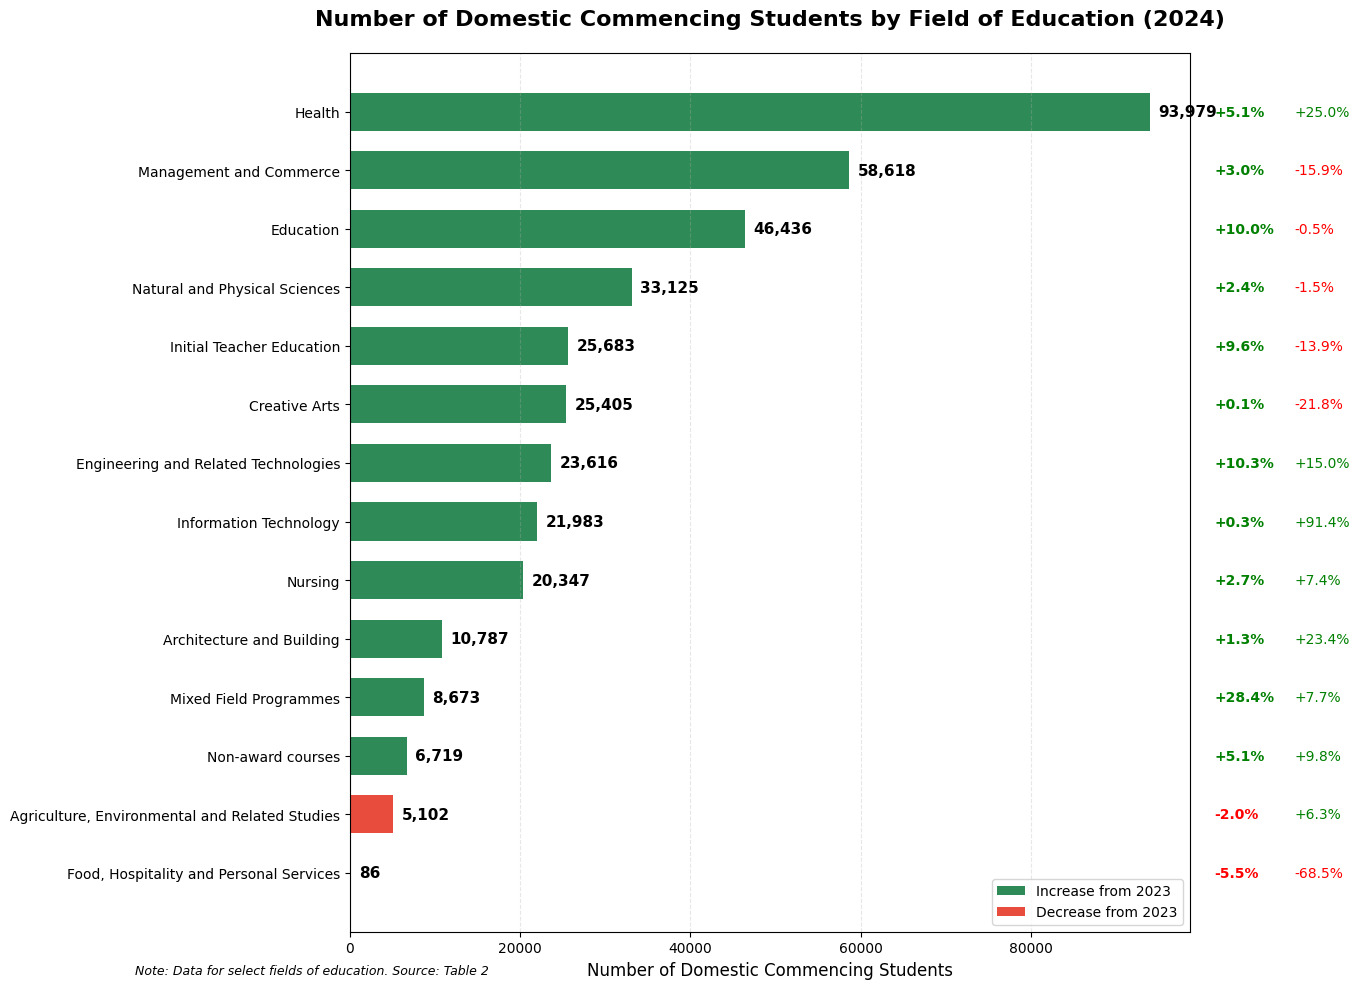

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data from Table 2
data = {
    'Field': [
        'Natural and Physical Sciences', 'Information Technology',
        'Engineering and Related Technologies', 'Architecture and Building',
        'Agriculture, Environmental and Related Studies', 'Health', 'Nursing',
        'Education', 'Initial Teacher Education', 'Management and Commerce',
        'Creative Arts', 'Food, Hospitality and Personal Services',
        'Mixed Field Programmes', 'Non-award courses'
    ],
    '2015': [33639, 11488, 20544, 8738, 4801, 75170, 18950, 46687, 29812, 69668, 32489, 273, 8056, 6118],
    '2023': [32363, 21917, 21416, 10652, 5208, 89396, 19817, 42208, 23426, 56917, 25372, 91, 6755, 6396],
    '2024': [33125, 21983, 23616, 10787, 5102, 93979, 20347, 46436, 25683, 58618, 25405, 86, 8673, 6719],
    'Change_2023_2024': [2.4, 0.3, 10.3, 1.3, -2.0, 5.1, 2.7, 10.0, 9.6, 3.0, 0.1, -5.5, 28.4, 5.1],
    'Change_2015_2024': [-1.5, 91.4, 15.0, 23.4, 6.3, 25.0, 7.4, -0.5, -13.9, -15.9, -21.8, -68.5, 7.7, 9.8]
}

df = pd.DataFrame(data)

# Sort by 2024 student numbers (largest to smallest)
df = df.sort_values(by='2024', ascending=False)


fig, ax = plt.subplots(figsize=(14, 10))

# Bar colors based on 2023 to 2024 change
colors = ['#2E8B57' if x >= 0 else '#E74C3C' for x in df['Change_2023_2024']]

bars = ax.barh(df['Field'], df['2024'], color=colors, height=0.65)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 1000, i, f'{int(df["2024"].iloc[i]):,}',
            va='center', fontsize=11, fontweight='bold')

# Add percentage change annotations
for i in range(len(df)):
    ch1 = df['Change_2023_2024'].iloc[i]
    ch2 = df['Change_2015_2024'].iloc[i]

    color1 = 'green' if ch1 >= 0 else 'red'
    color2 = 'green' if ch2 >= 0 else 'red'

    ax.text(df['2024'].max() * 1.08, i, f'{ch1:+.1f}%',
            va='center', color=color1, fontweight='bold')
    ax.text(df['2024'].max() * 1.18, i, f'{ch2:+.1f}%',
            va='center', color=color2, fontsize=10)

# Labels and title
ax.set_xlabel('Number of Domestic Commencing Students', fontsize=12)
ax.set_title('Number of Domestic Commencing Students by Field of Education (2024)',
             fontsize=16, fontweight='bold', pad=20)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E8B57', label='Increase from 2023'),
    Patch(facecolor='#E74C3C', label='Decrease from 2023')
]
ax.legend(handles=legend_elements, loc='lower right')

ax.invert_yaxis()  # Highest at top
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add source note
plt.figtext(0.1, 0.02,
            'Note: Data for select fields of education. Source: Table 2',
            fontsize=9, style='italic')

plt.tight_layout()
plt.show()

In [ ]:
"""
TNE Research Analysis: Australian Higher Education Enrolment Plots (2020-2024)
================================================================================

Generates a series of plots that connect the Department of Education enrolment
data to the TNE (Transnational Education) research findings:

  1. ANU vs. Go8 peers — total enrolment trajectory (2020-2024)
  2. ANU vs. comparable Go8 (UWA) — head-to-head benchmarking
  3. ANU's 2024 field-of-education mix (where TNE programmes could fit)
  4. Top 10 Australian universities by 2024 enrolment — scale comparison
  5. Australian HE growth rates 2020-2024 — winners and losers
  6. ANU's enrolment vs. NOSC shortfall context (TNE opportunity sizing)

Data source:
    Department of Education, Higher Education Statistics Collection,
    "Perturbed Student Enrolments Pivot Table 2024" (perturbed for disclosure
    control - not exact figures but reliable for trend analysis)

Author: Strategic Analysis Team
Date:   April 2026
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from pathlib import Path

# -----------------------------------------------------------------------------
# Plot styling - consistent palette aligned with prior TNE report visuals
# -----------------------------------------------------------------------------
ANU_COLOR     = "#1B3A5C"   # ANU navy
HIGHLIGHT     = "#B45309"   # warm accent (used in prior key-message highlights)
GO8_COLORS    = ["#2C5282", "#4A6FA5", "#7C9CC0", "#A4C2E0", "#3266AD",
                 "#534AB7", "#7C3AED"]  # cool palette for peer Go8 universities
NEUTRAL_GREY  = "#6B7280"
LIGHT_GREY    = "#E5E7EB"
SUCCESS_GREEN = "#059669"
DANGER_RED    = "#B91C1C"

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":         10,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlecolor":   "#1B3A5C",
    "axes.labelsize":    10,
    "axes.labelcolor":   "#374151",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.edgecolor":    "#9CA3AF",
    "axes.linewidth":    0.8,
    "xtick.color":       "#374151",
    "ytick.color":       "#374151",
    "grid.color":        "#E5E7EB",
    "grid.linewidth":    0.5,
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

# -----------------------------------------------------------------------------
# Load and clean the data
# -----------------------------------------------------------------------------
SRC = "/mnt/user-data/uploads/Perturbed_Student_Enrolments_Pivot_Table_2024.xlsx"
OUT = Path("/mnt/user-data/outputs")
OUT.mkdir(parents=True, exist_ok=True)

df_inst = pd.read_excel(SRC, sheet_name="Pivot", skiprows=24)
df_inst.columns = ["State", "Institution", 2020, 2021, 2022, 2023, 2024]
df_inst["State"] = df_inst["State"].ffill()
inst = df_inst[df_inst["Institution"].notna()].copy()
inst = inst[inst["Institution"] != "Grand Total"].reset_index(drop=True)

YEARS = [2020, 2021, 2022, 2023, 2024]

# Field of Education sheet (2024 only) - header row at index 23
df_foe = pd.read_excel(SRC, sheet_name="Pivot_BFOE", skiprows=23)
df_foe["State"] = df_foe["State"].ffill()
foe = df_foe[df_foe["Institution"].notna() & (df_foe["Institution"] != "Grand Total")].copy()


# -----------------------------------------------------------------------------
# PLOT 1: ANU vs. Go8 peers — total enrolment trajectory (2020-2024)
# -----------------------------------------------------------------------------
print("Generating Plot 1: ANU vs. Go8 enrolment trajectories...")

go8 = [
    "The Australian National University",
    "The University of Melbourne",
    "Monash University",
    "The University of Sydney",
    "University of New South Wales",
    "The University of Queensland",
    "The University of Western Australia",
    "The University of Adelaide",
]
go8_df = inst[inst["Institution"].isin(go8)].set_index("Institution")[YEARS]

fig, ax = plt.subplots(figsize=(11, 6.5))

# Plot peers in muted colours, then ANU in bold navy on top
peers = [u for u in go8 if u != "The Australian National University"]
for i, u in enumerate(peers):
    if u in go8_df.index:
        vals = go8_df.loc[u].values
        ax.plot(YEARS, vals, marker="o", markersize=5, linewidth=1.6,
                color=GO8_COLORS[i % len(GO8_COLORS)], alpha=0.55,
                label=u.replace("The University of ", "").replace("The ", "").replace("University", "Uni"))

# ANU on top, bold
anu_vals = go8_df.loc["The Australian National University"].values
ax.plot(YEARS, anu_vals, marker="o", markersize=8, linewidth=3.2,
        color=ANU_COLOR, label="ANU", zorder=10)

# Annotate ANU's start and end values
ax.annotate(f"{anu_vals[0]:,}", xy=(YEARS[0], anu_vals[0]),
            xytext=(-12, 8), textcoords="offset points",
            fontsize=9, color=ANU_COLOR, fontweight="bold", ha="right")
ax.annotate(f"{anu_vals[-1]:,}\n(\u22125.7%)", xy=(YEARS[-1], anu_vals[-1]),
            xytext=(8, -2), textcoords="offset points",
            fontsize=9, color=ANU_COLOR, fontweight="bold", ha="left")

ax.set_title("ANU has shrunk while most Go8 peers have grown\nTotal enrolments by Go8 university, 2020\u20132024", loc="left", pad=14)
ax.set_xlabel("Year")
ax.set_ylabel("Total student enrolments")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax.set_xticks(YEARS)
ax.grid(True, axis="y", alpha=0.5)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))

fig.text(0.01, 0.01,
         "Source: Australian Department of Education, Higher Education Statistics Collection 2024 (perturbed pivot data)",
         fontsize=8, color=NEUTRAL_GREY, style="italic")

plt.tight_layout()
plt.savefig(OUT / "plot1_anu_vs_go8_trajectory.png", dpi=200, bbox_inches="tight")
plt.close()


# -----------------------------------------------------------------------------
# PLOT 2: ANU vs. UWA - head-to-head Go8 size-comparable benchmark
# -----------------------------------------------------------------------------
print("Generating Plot 2: ANU vs. UWA head-to-head...")

fig, ax = plt.subplots(figsize=(10, 6))

anu = inst[inst["Institution"] == "The Australian National University"][YEARS].values.flatten()
uwa = inst[inst["Institution"] == "The University of Western Australia"][YEARS].values.flatten()

ax.plot(YEARS, anu, marker="o", markersize=10, linewidth=3.2,
        color=ANU_COLOR, label="ANU", zorder=5)
ax.plot(YEARS, uwa, marker="s", markersize=10, linewidth=3.2,
        color=HIGHLIGHT, label="UWA (closest Go8 size comparator)", zorder=5)

# Fill between to show widening gap
ax.fill_between(YEARS, anu, uwa, where=(uwa >= anu),
                color=HIGHLIGHT, alpha=0.08, interpolate=True)

# Annotations
for x, y in zip(YEARS, anu):
    ax.annotate(f"{y:,}", xy=(x, y), xytext=(0, -16), textcoords="offset points",
                ha="center", fontsize=8.5, color=ANU_COLOR, fontweight="bold")
for x, y in zip(YEARS, uwa):
    ax.annotate(f"{y:,}", xy=(x, y), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8.5, color=HIGHLIGHT, fontweight="bold")

# Growth callouts
anu_growth = (anu[-1] - anu[0]) / anu[0] * 100
uwa_growth = (uwa[-1] - uwa[0]) / uwa[0] * 100
ax.text(0.02, 0.97,
        f"ANU 2020\u20132024: {anu_growth:+.1f}%\nUWA 2020\u20132024: {uwa_growth:+.1f}%",
        transform=ax.transAxes, fontsize=10, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.5", fc="#FEF3C7", ec="#B45309", lw=1))

ax.set_title("UWA is now ahead of ANU in total enrolments\u2014and is moving on TNE first\nANU vs. UWA total enrolments, 2020\u20132024", loc="left", pad=14)
ax.set_xlabel("Year")
ax.set_ylabel("Total student enrolments")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax.set_xticks(YEARS)
ax.grid(True, axis="y", alpha=0.5)
ax.legend(loc="lower right")

fig.text(0.01, 0.01,
         "Source: Australian Department of Education, Higher Education Statistics Collection 2024. UWA approved for India branch campuses (UGC, June 2025); ANU yet to announce TNE entry.",
         fontsize=8, color=NEUTRAL_GREY, style="italic")

plt.tight_layout()
plt.savefig(OUT / "plot2_anu_vs_uwa_headtohead.png", dpi=200, bbox_inches="tight")
plt.close()


# -----------------------------------------------------------------------------
# PLOT 3: ANU's 2024 field-of-education mix (TNE programme opportunity)
# -----------------------------------------------------------------------------
print("Generating Plot 3: ANU 2024 Field of Education mix...")

anu_foe = foe[foe["Institution"] == "The Australian National University"].iloc[0]
foe_categories = [c for c in foe.columns if c not in ["State", "Institution", "Total Enrolments"]]
anu_foe_values = {cat: anu_foe[cat] for cat in foe_categories if pd.notna(anu_foe[cat]) and anu_foe[cat] > 0}

# Sort and prep
sorted_foe = sorted(anu_foe_values.items(), key=lambda x: x[1], reverse=True)
labels  = [k for k, _ in sorted_foe]
values  = [v for _, v in sorted_foe]
total   = sum(values)
pcts    = [v / total * 100 for v in values]

# Annotate which fields align with TNE opportunity
TNE_ALIGNED = {
    "Management and Commerce":   ("\u2605 TNE-aligned (top demand from India/Vietnam)", SUCCESS_GREEN),
    "Information Technology":    ("\u2605 TNE-aligned (top demand from India/Vietnam)", SUCCESS_GREEN),
    "Society and Culture":       ("\u25CF ANU policy/IR strength (differentiated TNE niche)", HIGHLIGHT),
    "Engineering and Related Technologies": ("\u25CB Possible TNE expansion", "#7C9CC0"),
    "Natural and Physical Sciences": ("\u25CB Strong subject ranking; possible TNE", "#7C9CC0"),
}

fig, ax = plt.subplots(figsize=(11, 7))

bar_colors = []
for lab in labels:
    if lab in TNE_ALIGNED:
        bar_colors.append(TNE_ALIGNED[lab][1])
    else:
        bar_colors.append(LIGHT_GREY)

bars = ax.barh(labels, values, color=bar_colors, edgecolor="white", linewidth=0.8)

# Annotate values and TNE flags
for bar, v, p, lab in zip(bars, values, pcts, labels):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f"{int(v):,} ({p:.1f}%)", va="center", fontsize=9, color="#374151")
    if lab in TNE_ALIGNED:
        flag, _ = TNE_ALIGNED[lab]
        ax.text(60, bar.get_y() + bar.get_height()/2 - 0.2,
                flag, va="center", fontsize=8, color="white", fontweight="bold",
                style="italic")

ax.invert_yaxis()
ax.set_title("ANU\u2019s strongest fields are precisely where TNE demand is concentrated\nANU 2024 enrolments by Broad Field of Education", loc="left", pad=14)
ax.set_xlabel("Number of students enrolled")
ax.set_xlim(0, max(values) * 1.18)
ax.grid(True, axis="x", alpha=0.5)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=SUCCESS_GREEN, label="TNE-aligned (high India/Vietnam demand)"),
    Patch(facecolor=HIGHLIGHT,     label="ANU differentiated TNE niche (policy/IR/society)"),
    Patch(facecolor="#7C9CC0",     label="Possible TNE expansion"),
    Patch(facecolor=LIGHT_GREY,    label="Other fields"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig.text(0.01, 0.01,
         "Source: Australian Department of Education, Higher Education Statistics Collection 2024 (Pivot_BFOE sheet, perturbed). " +
         "TNE alignment based on Indian/Vietnamese student preferences in Australia onshore (PRISMS, 2025).",
         fontsize=8, color=NEUTRAL_GREY, style="italic")

plt.tight_layout()
plt.savefig(OUT / "plot3_anu_field_of_education_mix.png", dpi=200, bbox_inches="tight")
plt.close()

print("Generating Plot 4: Top 10 by 2024 enrolment...")

# Filter to real universities only (exclude aggregators and non-uni providers)
def is_real_uni_for_top10(name):
    if pd.isna(name): return False
    n = str(name)
    excludes = ["Non-University", "Private Universities", "Multi-State"]
    return not any(x in n for x in excludes)

real_unis = inst[inst["Institution"].apply(is_real_uni_for_top10)].copy()
top10 = real_unis.nlargest(10, 2024)[["Institution", 2024]].copy()
top10["short"] = (top10["Institution"]
                  .str.replace("The University of ", "")
                  .str.replace("The ", "")
                  .str.replace(" University", "")
                  .str.replace("Australian National", "ANU")
                  .str.replace(" Australia", "")
                  .str.replace("of Technology", "Technology")
                  .str.replace(" Sydney", " Sydney"))

# Find ANU's overall rank among real unis
anu_rank_overall = (real_unis.sort_values(2024, ascending=False)
                    .reset_index(drop=True))
anu_overall_rank = anu_rank_overall[anu_rank_overall["Institution"]
                                    == "The Australian National University"].index[0] + 1
anu_2024_val = inst[inst["Institution"] == "The Australian National University"][2024].values[0]

fig, ax = plt.subplots(figsize=(11, 6.8))

bar_colors = []
for s in top10["short"]:
    if "ANU" in s:
        bar_colors.append(ANU_COLOR)
    elif "Western Australia" in s or s == "Western":
        bar_colors.append(HIGHLIGHT)
    else:
        bar_colors.append("#A4C2E0")

bars = ax.bar(top10["short"], top10[2024], color=bar_colors, edgecolor="white", linewidth=1)

for bar, v in zip(bars, top10[2024]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1200,
            f"{int(v/1000)}k", ha="center", fontsize=9, color="#374151", fontweight="bold")

# Set y-limit higher to give room for the annotation
ax.set_ylim(0, max(top10[2024]) * 1.30)

# Annotation positioned above bars in upper-right space
ax.text(0.97, 0.97,
        f"ANU is ranked #{anu_overall_rank} by 2024 enrolment ({int(anu_2024_val):,} students)\n"
        "\u2014 below the top 10 by scale, but #32 in QS World 2026.\n"
        "This scale gap structurally limits ranking indicators\n"
        "that reward size (e.g. faculty-student ratio).",
        transform=ax.transAxes, fontsize=9.5, va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.6", fc="#FEF3C7", ec="#B45309", lw=1))

ax.set_title("ANU\u2019s small scale is a structural ranking disadvantage\nTop 10 Australian universities by 2024 total enrolment", loc="left", pad=14)
ax.set_ylabel("Total student enrolments (2024)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
plt.xticks(rotation=30, ha="right")
ax.grid(True, axis="y", alpha=0.5)

fig.text(0.01, 0.01,
         "Source: Australian Department of Education, Higher Education Statistics Collection 2024 (perturbed pivot). Excludes non-university provider aggregates.",
         fontsize=8, color=NEUTRAL_GREY, style="italic")

plt.tight_layout()
plt.savefig(OUT / "plot4_top10_2024_enrolment.png", dpi=200, bbox_inches="tight")
plt.close()

print("Generating Plot 5: Growth rates 2020-2024...")

# Filter to universities (drop "Non-University..." aggregates and small ones)
exclude_terms = ["Non-University", "Private Universities", "Carnegie Mellon",
                 "University of Divinity", "Avondale", "Batchelor",
                 "Multi-State"]
def is_real_uni(name):
    if pd.isna(name): return False
    name_str = str(name)
    for t in exclude_terms:
        if t in name_str:
            return False
    return True

unis = inst[inst["Institution"].apply(is_real_uni)].copy()
unis["growth"] = (unis[2024] - unis[2020]) / unis[2020] * 100
unis = unis.sort_values("growth", ascending=True)
unis["short"] = unis["Institution"].str.replace("The University of ", "").str.replace("The ", "").str.replace(" University", "").str.replace("Australian National", "ANU").str.replace(" Australia", "")

fig, ax = plt.subplots(figsize=(10, 9))

bar_colors = []
for _, row in unis.iterrows():
    if "ANU" in row["short"]:
        bar_colors.append(ANU_COLOR)
    elif row["growth"] >= 0:
        bar_colors.append(SUCCESS_GREEN)
    else:
        bar_colors.append(DANGER_RED)
    # Highlight UWA
    if "Western Australia" in row["Institution"]:
        bar_colors[-1] = HIGHLIGHT

bars = ax.barh(unis["short"], unis["growth"], color=bar_colors, edgecolor="white", linewidth=0.6)

for bar, g in zip(bars, unis["growth"]):
    x = bar.get_width()
    ha = "left" if x >= 0 else "right"
    offset = 0.4 if x >= 0 else -0.4
    ax.text(x + offset, bar.get_y() + bar.get_height()/2,
            f"{g:+.1f}%", va="center", ha=ha, fontsize=8, color="#374151")

ax.axvline(0, color="#374151", linewidth=0.8)
ax.set_title("ANU declined while comparable Go8 peers grew\nTotal enrolment growth, 2020\u20132024, Australian universities", loc="left", pad=14)
ax.set_xlabel("Total enrolment change, 2020\u20132024 (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(True, axis="x", alpha=0.5)

# Legend
legend_elements = [
    Patch(facecolor=ANU_COLOR,     label="ANU"),
    Patch(facecolor=HIGHLIGHT,     label="UWA (closest Go8 size comparator)"),
    Patch(facecolor=SUCCESS_GREEN, label="Other universities (positive growth)"),
    Patch(facecolor=DANGER_RED,    label="Other universities (negative growth)"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig.text(0.01, 0.01,
         "Source: Australian Department of Education, Higher Education Statistics Collection 2024 (perturbed pivot). Excludes non-university providers and aggregates.",
         fontsize=8, color=NEUTRAL_GREY, style="italic")

plt.tight_layout()
plt.savefig(OUT / "plot5_growth_2020_2024.png", dpi=200, bbox_inches="tight")
plt.close()


# -----------------------------------------------------------------------------
# PLOT 6: ANU enrolment trajectory + TNE opportunity sizing (counterfactual)
# -----------------------------------------------------------------------------
print("Generating Plot 6: ANU + TNE counterfactual...")

fig, ax = plt.subplots(figsize=(12, 7))

# Historical ANU enrolment (2020-2024)
ax.plot(YEARS, anu, marker="o", markersize=10, linewidth=3.2,
        color=ANU_COLOR, label="ANU actual (2020\u20132024, DoE data)", zorder=5)

# Bridge from 2024 actual into projection - start projection at 2024 end value
proj_years = list(range(2024, 2031))   # 2024..2030
flat_baseline = [anu[-1]] * len(proj_years)
# TNE adds: Year 0=0, Y1=300/350, Y2=700/800, Y3=1150/1300, Y4=1700/1900, Y5=2000/2500, Y6=continued
tne_low  = [0,   0, 300,  700, 1150, 1700, 2000]
tne_high = [0,   0, 350,  800, 1300, 1900, 2500]

# Without-TNE baseline (flat from 2024)
ax.plot(proj_years, flat_baseline, marker="o", markersize=7, linewidth=2.4,
        color=NEUTRAL_GREY, linestyle="--",
        label="ANU without TNE (flat baseline projection)", zorder=4)

# With-TNE high-case
with_tne_high = [b + h for b, h in zip(flat_baseline, tne_high)]
ax.plot(proj_years, with_tne_high, marker="^", markersize=8, linewidth=2.8,
        color=SUCCESS_GREEN, linestyle="-",
        label="ANU + TNE (high case projection)", zorder=4)

# Projection range fill
with_tne_low = [b + l for b, l in zip(flat_baseline, tne_low)]
ax.fill_between(proj_years, with_tne_low, with_tne_high,
                color=SUCCESS_GREEN, alpha=0.18, label="TNE projection range")

# Vertical separator between historical and projection - aligned with 2024
ax.axvline(2024, color=NEUTRAL_GREY, linewidth=1, linestyle=":", alpha=0.6)
ax.text(2024.05, 27500, "  Projection \u2192", fontsize=9, color=NEUTRAL_GREY,
        style="italic", ha="left")
ax.text(2023.95, 27500, "Historical  ", fontsize=9, color=NEUTRAL_GREY,
        style="italic", ha="right")

# Annotate Year 5 TNE upside (which is 2029, the 5th projection year after 2024)
year5_x = 2029
year5_y = with_tne_high[5]   # index 5 = 2029
ax.annotate(
    "Year 5 TNE upside:\n+2,000\u20132,500 students\n(\u2248A$30\u201350M revenue)\nNOSC-exempt revenue",
    xy=(year5_x, year5_y),
    xytext=(2025.5, 28800),
    fontsize=10, color=SUCCESS_GREEN, fontweight="bold", ha="left",
    bbox=dict(boxstyle="round,pad=0.5", fc="#ECFDF5", ec=SUCCESS_GREEN, lw=1.2),
    arrowprops=dict(arrowstyle="->", color=SUCCESS_GREEN, lw=1.5))

# Annotate the 2024 actual point
ax.annotate(f"2024 actual: {int(anu[-1]):,}",
            xy=(2024, anu[-1]),
            xytext=(2022, 21500),
            fontsize=9, color=ANU_COLOR, fontweight="bold",
            ha="center",
            arrowprops=dict(arrowstyle="->", color=ANU_COLOR, lw=1.2, alpha=0.7))

ax.set_title("TNE could add 9\u201311% to ANU\u2019s student base by 2030\nANU enrolment 2020\u20132024 (actual) and 2024\u20132030 with TNE (projected)",
             loc="left", pad=14)
ax.set_xlabel("Year")
ax.set_ylabel("Total student enrolments")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax.set_xticks(YEARS + [2025, 2026, 2027, 2028, 2029, 2030])
ax.set_ylim(20500, 30500)
ax.grid(True, axis="y", alpha=0.5)
ax.legend(loc="upper left", framealpha=0.95)

fig.text(0.01, 0.01,
         "Sources: Historical \u2014 Australian Department of Education 2024. Projections \u2014 calculated from peer benchmarks " +
         "(Monash Malaysia: 11k+ students; Deakin GIFT City: opened 2024; WSU\u2013UEH Vietnam: 3,000+ graduates over a decade).",
         fontsize=8, color=NEUTRAL_GREY, style="italic")

plt.tight_layout()
plt.savefig(OUT / "plot6_tne_counterfactual.png", dpi=200, bbox_inches="tight")
plt.close()


# -----------------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("All 6 plots generated successfully:")
for i, name in enumerate([
    "plot1_anu_vs_go8_trajectory.png",
    "plot2_anu_vs_uwa_headtohead.png",
    "plot3_anu_field_of_education_mix.png",
    "plot4_top10_2024_enrolment.png",
    "plot5_growth_2020_2024.png",
    "plot6_tne_counterfactual.png",
], 1):
    print(f"  Plot {i}: {OUT / name}")
print("="*70)

# Print the key numbers for traceability
print("\nKey data points underpinning the plots:")
print(f"  ANU 2020 enrolment: {int(anu[0]):,}")
print(f"  ANU 2024 enrolment: {int(anu[-1]):,}")
print(f"  ANU 2020-2024 change: {(anu[-1]-anu[0])/anu[0]*100:+.1f}%")
print(f"  UWA 2020 enrolment: {int(uwa[0]):,}")
print(f"  UWA 2024 enrolment: {int(uwa[-1]):,}")
print(f"  UWA 2020-2024 change: {(uwa[-1]-uwa[0])/uwa[0]*100:+.1f}%")
print(f"\n  ANU Top FOE 2024:")
for k, v in sorted_foe[:5]:
    print(f"    {k}: {int(v):,}")

In [ ]:
"""
Plot 1 and Plot 7 — ANU TNE Report
Colour palette and font spec applied exactly as provided.
"""
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
from pathlib import Path

# ── Font & colour setup ───────────────────────────────────────────────
NAVY      = "#1C2D5E"   # from colour strip
NAVY_MID  = "#2E4478"   # slightly lighter navy for secondary bars
NAVY_LITE = "#7B8EC8"   # light navy for qualitative/accent
NAVY_PALE = "#D6DCF0"   # very pale navy for hatching fill
GOLD      = "#C9A227"   # ANU gold — kept for ANU highlight only
WHITE     = "#FFFFFF"
TEXT      = "#1A1A2E"   # near-black for body text
GRID      = "#C8CDD8"   # subtle grey grid

BASE      = 12          # base font size (pt)
FONT      = "TeX Gyre Termes"

plt.rcParams.update({
    "font.family":         FONT,
    "font.size":           BASE,
    "axes.titlesize":      BASE,
    "axes.titleweight":    "bold",
    "axes.labelsize":      BASE,
    "axes.edgecolor":      NAVY,
    "axes.linewidth":      0.9,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.spines.left":    True,
    "axes.spines.bottom":  True,
    "xtick.color":         TEXT,
    "ytick.color":         TEXT,
    "xtick.labelsize":     BASE,
    "ytick.labelsize":     BASE,
    "figure.dpi":          150,
    "text.color":          TEXT,
})

# ── Paths ─────────────────────────────────────────────────────────────
PIVOT_SRC = "/mnt/user-data/uploads/Perturbed_Student_Enrolments_Pivot_Table_2024.xlsx"
SECT7_SRC = "/mnt/user-data/uploads/2024_Section7_Overseas_Students.xlsx"
OUT       = Path("/mnt/user-data/outputs")
YEARS     = [2020, 2021, 2022, 2023, 2024]

# Qualitative palette for Go8 peers — navy family graduated shades
PEER_COLORS = [
    NAVY_MID,        # Melbourne
    NAVY_LITE,       # Monash
    "#4A63A0",       # Sydney
    "#9DAED8",       # UNSW
    "#5C76B3",       # Queensland
    "#B0BBD9",       # UWA
    "#3A558E",       # Adelaide
]

# ─────────────────────────────────────────────────────────────────────
# Load data
# ─────────────────────────────────────────────────────────────────────
df_inst = pd.read_excel(PIVOT_SRC, sheet_name="Pivot", skiprows=24)
df_inst.columns = ["State", "Institution", 2020, 2021, 2022, 2023, 2024]
df_inst["State"] = df_inst["State"].ffill()
inst = df_inst[df_inst["Institution"].notna() & (df_inst["Institution"] != "Grand Total")].copy()

go8 = [
    "The Australian National University",
    "The University of Melbourne",
    "Monash University",
    "The University of Sydney",
    "University of New South Wales",
    "The University of Queensland",
    "The University of Western Australia",
    "The University of Adelaide",
]
go8_df = inst[inst["Institution"].isin(go8)].set_index("Institution")[YEARS]
anu_vals = go8_df.loc["The Australian National University"].values


# ═════════════════════════════════════════════════════════════════════
# PLOT 1 — ANU vs. Go8 enrolment trajectories
# ═════════════════════════════════════════════════════════════════════
print("Generating Plot 1…")

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor=WHITE)
ax.set_facecolor(WHITE)

peers = [u for u in go8 if u != "The Australian National University"]
for i, u in enumerate(peers):
    if u not in go8_df.index:
        continue
    vals = go8_df.loc[u].values
    short = (u.replace("The University of ", "")
              .replace("The ", "")
              .replace("University", "Uni")
              .strip())
    ax.plot(YEARS, vals,
            marker="o", markersize=5, linewidth=1.6,
            color=PEER_COLORS[i % len(PEER_COLORS)],
            alpha=0.70, label=short)

# ANU in gold — bold, on top
ax.plot(YEARS, anu_vals,
        marker="o", markersize=9, linewidth=3.0,
        color=GOLD, label="ANU", zorder=10)

# Annotate ANU start and end
ax.annotate(f"{anu_vals[0]:,}",
            xy=(YEARS[0], anu_vals[0]),
            xytext=(-14, 8), textcoords="offset points",
            fontsize=BASE, color=GOLD, fontweight="bold", ha="right")
ax.annotate(f"{anu_vals[-1]:,}\n(\u22125.7%)",
            xy=(YEARS[-1], anu_vals[-1]),
            xytext=(8, -2), textcoords="offset points",
            fontsize=BASE, color=GOLD, fontweight="bold", ha="left")

ax.set_title(
    "ANU has shrunk while most Go8 peers have grown\n"
    "Total enrolments by Go8 university, 2020\u20132024",
    loc="left", pad=14, color=NAVY)
ax.set_xlabel("Year")
ax.set_ylabel("Total student enrolments")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax.set_xticks(YEARS)
ax.grid(True, axis="y", color=GRID, linewidth=0.5, linestyle="-")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=BASE,
          frameon=False)

fig.text(0.01, 0.01,
         "Source: Australian Department of Education, "
         "Higher Education Statistics Collection 2024 (perturbed pivot data)",
         fontsize=9, color="#6B7280", style="italic")

plt.tight_layout()
plt.savefig(OUT / "plot1_anu_vs_go8_trajectory.png",
            dpi=150, bbox_inches="tight", facecolor=WHITE)
plt.close()
print("  → plot1 saved")


# ═════════════════════════════════════════════════════════════════════
# PLOT 7 — Overseas EFTSL gap + sector field growth
# ═════════════════════════════════════════════════════════════════════
print("Generating Plot 7…")

df75 = pd.read_excel(SECT7_SRC, sheet_name="7.5", skiprows=2)
df75 = df75[
    df75["Institution"].notna() &
    ~df75["Institution"].astype(str).str.contains("Non-University", na=False)
].copy()
df75["Institution"] = (df75["Institution"].astype(str)
                        .str.replace(r"\(.*\)", "", regex=True).str.strip())

go8_names = [
    "The Australian National University",
    "The University of Western Australia",
    "The University of Adelaide",
    "The University of Queensland",
    "Monash University",
    "The University of Sydney",
    "University of New South Wales",
    "The University of Melbourne",
]
go8e = (df75[df75["Institution"].isin(go8_names)]
        .sort_values("Total Load", ascending=True).copy())
go8e["short"] = (go8e["Institution"]
                  .str.replace("The University of ", "")
                  .str.replace("The ", "")
                  .str.replace("University", "")
                  .str.replace("Australian National", "ANU")
                  .str.strip())

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 5.5),
    gridspec_kw={"width_ratios": [1.4, 1]},
    facecolor=WHITE)
ax1.set_facecolor(WHITE)
ax2.set_facecolor(WHITE)

# ── Left: overseas EFTSL by Go8 ───────────────────────────────────────
bar_colors = []
for s in go8e["short"]:
    if s == "ANU":
        bar_colors.append(GOLD)          # ANU in gold
    elif "Western Australia" in s:
        bar_colors.append(NAVY_LITE)     # UWA comparator — light navy
    else:
        bar_colors.append(NAVY_PALE)     # peers — pale navy

bars = ax1.barh(go8e["short"], go8e["Total Load"],
                color=bar_colors, edgecolor=NAVY, linewidth=0.5)

for bar, v in zip(bars, go8e["Total Load"]):
    ax1.text(bar.get_width() + 400,
             bar.get_y() + bar.get_height() / 2,
             f"{int(v):,}", va="center",
             fontsize=BASE, color=TEXT, fontweight="bold")

ax1.set_title(
    "ANU has the smallest overseas student EFTSL of any Go8\n"
    "Overseas student EFTSL by Go8 university, 2024",
    loc="left", pad=12, color=NAVY)
ax1.set_xlabel("Overseas student EFTSL (2024)")
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax1.set_xlim(0, max(go8e["Total Load"]) * 1.22)
ax1.grid(True, axis="x", color=GRID, linewidth=0.5)

legend1 = [
    Patch(facecolor=GOLD,      edgecolor=NAVY, linewidth=0.5, label="ANU"),
    Patch(facecolor=NAVY_LITE, edgecolor=NAVY, linewidth=0.5,
          label="UWA (closest size comparator)"),
    Patch(facecolor=NAVY_PALE, edgecolor=NAVY, linewidth=0.5,
          label="Other Go8 universities"),
]
ax1.legend(handles=legend1, loc="lower right", fontsize=BASE, frameon=False)

# ── Right: sector field growth 2023→2024 ──────────────────────────────
fields_growth = {
    "Education":               59.8,
    "Information Technology":  21.7,
    "Health":                  13.1,
    "Natural & Phys. Sci.":    10.6,
    "Agric./Environment":       9.2,
    "Engineering":              9.2,
    "Architecture & Building": -0.8,
}
fields = list(fields_growth.keys())
growth = list(fields_growth.values())

# Positive = NAVY_MID, negative = pale-with-navy-edge
field_colors = [NAVY_MID if g > 0 else NAVY_PALE for g in growth]
field_edge   = [NAVY for _ in growth]

b2 = ax2.barh(fields, growth,
              color=field_colors, edgecolor=field_edge, linewidth=0.5)
for bar, g in zip(b2, growth):
    x = bar.get_width()
    ha = "left" if x >= 0 else "right"
    ax2.text(x + (1 if x >= 0 else -1),
             bar.get_y() + bar.get_height() / 2,
             f"{g:+.1f}%", va="center", ha=ha,
             fontsize=BASE, color=TEXT, fontweight="bold")

ax2.invert_yaxis()
ax2.axvline(0, color=NAVY, linewidth=0.8)
ax2.set_title(
    "Sector overseas demand is growing\u2014especially\n"
    "in fields where ANU is small\n"
    "(All Australian HE, 2023\u20132024 % change)",
    loc="left", pad=12, color=NAVY)
ax2.set_xlabel("Year-on-year change in overseas students (%)")
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax2.set_xlim(-10, 70)
ax2.grid(True, axis="x", color=GRID, linewidth=0.5)

fig.text(0.005, 0.005,
         "Source: Australian Department of Education, 2024 Higher Education Student Data, "
         "Section 7 Overseas Students (Tables 7.2, 7.5).",
         fontsize=9, color="#6B7280", style="italic")

plt.tight_layout()
plt.savefig(OUT / "plot7_overseas_eftsl_gap.png",
            dpi=150, bbox_inches="tight", facecolor=WHITE)
plt.close()
print("  → plot7 saved")
print("\nDone.")

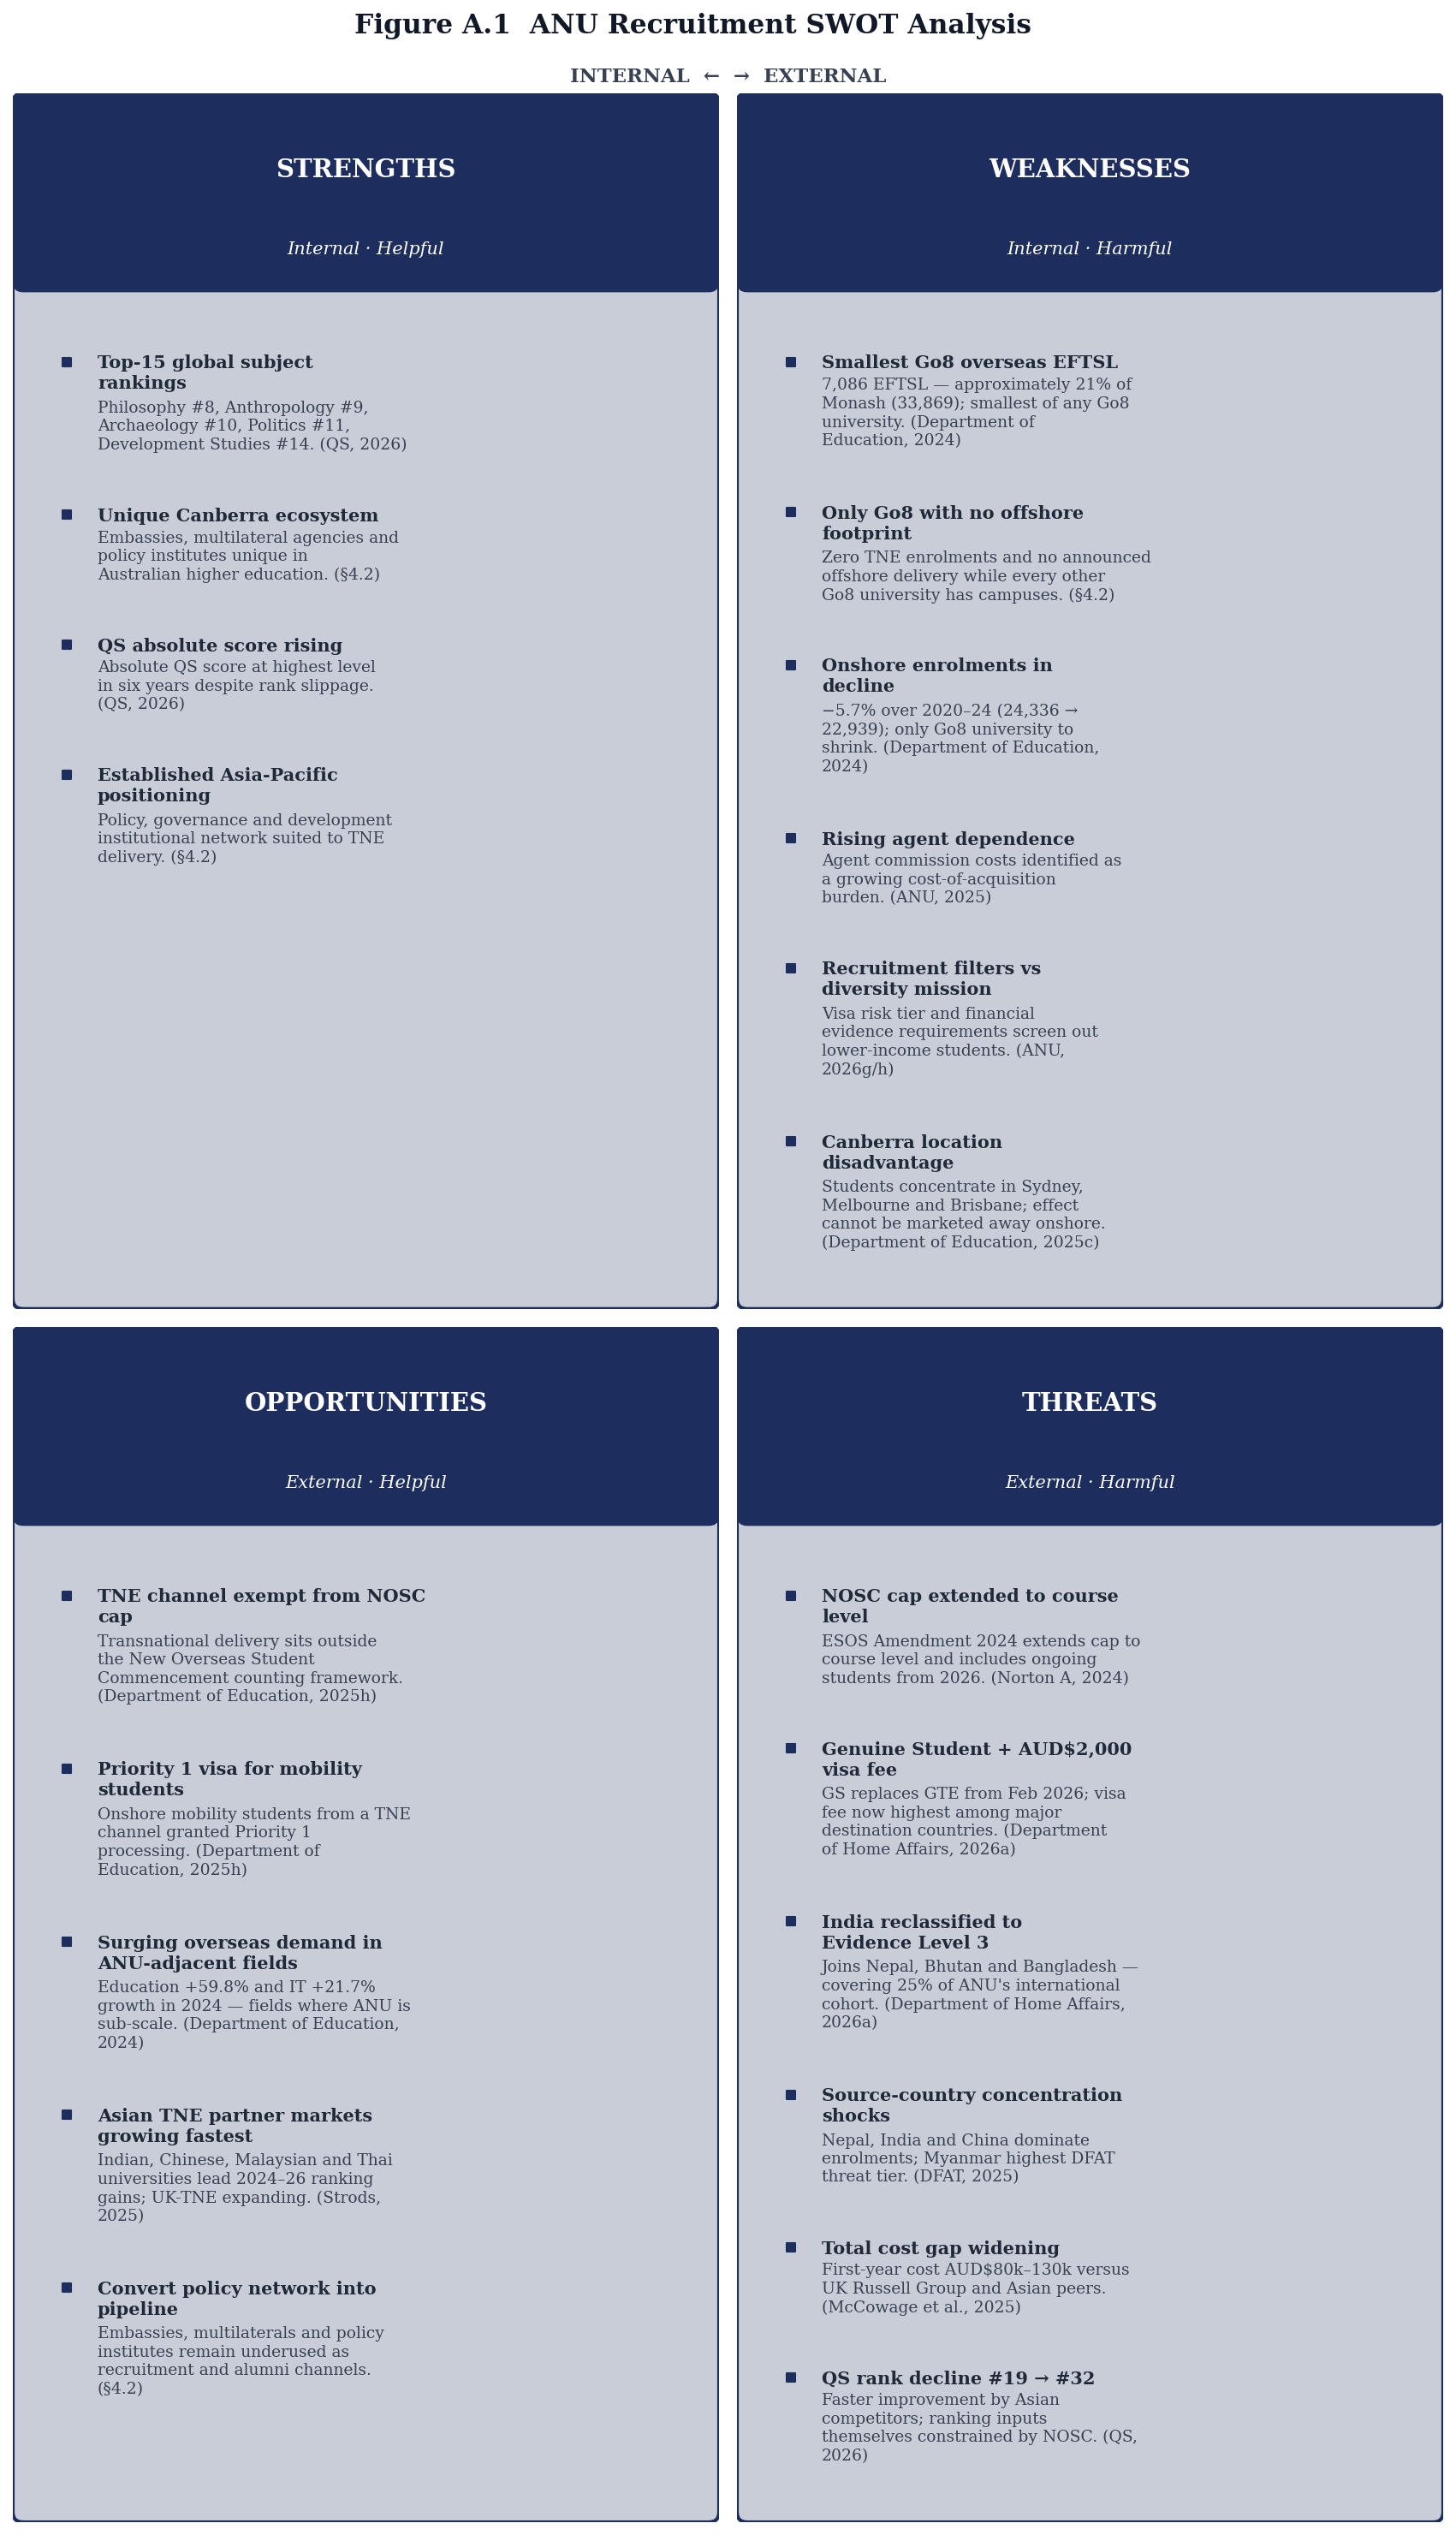

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "figure.dpi": 150,
})

S_COLOR = "#1C2D5E"
W_COLOR = "#1C2D5E"
O_COLOR = "#1C2D5E"
T_COLOR = "#1C2D5E"
S_FILL = "#C8CDD8"
W_FILL = "#C8CDD8"
O_FILL = "#C8CDD8"
T_FILL = "#C8CDD8"

strengths = [
    ("Top-15 global subject rankings",
     "Philosophy #8, Anthropology #9, Archaeology #10, Politics #11, Development Studies #14. (QS, 2026)"),
    ("Unique Canberra ecosystem",
     "Embassies, multilateral agencies and policy institutes unique in Australian higher education. (§4.2)"),
    ("QS absolute score rising",
     "Absolute QS score at highest level in six years despite rank slippage. (QS, 2026)"),
    ("Established Asia-Pacific positioning",
     "Policy, governance and development institutional network suited to TNE delivery. (§4.2)"),
]

weaknesses = [
    ("Smallest Go8 overseas EFTSL",
     "7,086 EFTSL — approximately 21% of Monash (33,869); smallest of any Go8 university. (Department of Education, 2024)"),
    ("Only Go8 with no offshore footprint",
     "Zero TNE enrolments and no announced offshore delivery while every other Go8 university has campuses. (§4.2)"),
    ("Onshore enrolments in decline",
     "−5.7% over 2020–24 (24,336 → 22,939); only Go8 university to shrink. (Department of Education, 2024)"),
    ("Rising agent dependence",
     "Agent commission costs identified as a growing cost-of-acquisition burden. (ANU, 2025)"),
    ("Recruitment filters vs diversity mission",
     "Visa risk tier and financial evidence requirements screen out lower-income students. (ANU, 2026g/h)"),
    ("Canberra location disadvantage",
     "Students concentrate in Sydney, Melbourne and Brisbane; effect cannot be marketed away onshore. (Department of Education, 2025c)"),
]

opportunities = [
    ("TNE channel exempt from NOSC cap",
     "Transnational delivery sits outside the New Overseas Student Commencement counting framework. (Department of Education, 2025h)"),
    ("Priority 1 visa for mobility students",
     "Onshore mobility students from a TNE channel granted Priority 1 processing. (Department of Education, 2025h)"),
    ("Surging overseas demand in ANU-adjacent fields",
     "Education +59.8% and IT +21.7% growth in 2024 — fields where ANU is sub-scale. (Department of Education, 2024)"),
    ("Asian TNE partner markets growing fastest",
     "Indian, Chinese, Malaysian and Thai universities lead 2024–26 ranking gains; UK-TNE expanding. (Strods, 2025)"),
    ("Convert policy network into pipeline",
     "Embassies, multilaterals and policy institutes remain underused as recruitment and alumni channels. (§4.2)"),
]

threats = [
    ("NOSC cap extended to course level",
     "ESOS Amendment 2024 extends cap to course level and includes ongoing students from 2026. (Norton A, 2024)"),
    ("Genuine Student + AUD$2,000 visa fee",
     "GS replaces GTE from Feb 2026; visa fee now highest among major destination countries. (Department of Home Affairs, 2026a)"),
    ("India reclassified to Evidence Level 3",
     "Joins Nepal, Bhutan and Bangladesh — covering 25% of ANU's international cohort. (Department of Home Affairs, 2026a)"),
    ("Source-country concentration shocks",
     "Nepal, India and China dominate enrolments; Myanmar highest DFAT threat tier. (DFAT, 2025)"),
    ("Total cost gap widening",
     "First-year cost AUD$80k–130k versus UK Russell Group and Asian peers. (McCowage et al., 2025)"),
    ("QS rank decline #19 → #32",
     "Faster improvement by Asian competitors; ranking inputs themselves constrained by NOSC. (QS, 2026)"),
]

# ── Layout constants scaled for 12 pt ────────────────────────────────────────
TITLE_WRAP  = 28          # chars before wrapping a bullet title
BODY_WRAP   = 36          # chars before wrapping body text
TITLE_FS    = 10.0        # bullet title font size (pt)
BODY_FS     =  9.0        # body font size (pt)
BULLET_SIZE = 22          # scatter marker size
HEADER_H    =  1.55       # header band height (inches)
ITEM_PAD_TOP = 0.20
ITEM_PAD_BOT = 0.16
TITLE_LINE_H = 0.178      # height per wrapped title line (inches)
BODY_LINE_H  = 0.158      # height per wrapped body line (inches)
QUAD_PAD_TOP = 0.28
QUAD_PAD_BOT = 0.22
QUAD_PAD_LR  = 0.20
BULLET_X_OFF = 0.22
TEXT_X_OFF   = 0.46
GAP          = 0.14       # gap between quadrants (inches)


def measure_item(title, body):
    t_lines = len(textwrap.wrap(title, TITLE_WRAP))
    b_lines = len(textwrap.wrap(body,  BODY_WRAP))
    return ITEM_PAD_TOP + t_lines * TITLE_LINE_H + b_lines * BODY_LINE_H + ITEM_PAD_BOT


def measure_quad_h(items):
    total = HEADER_H + QUAD_PAD_TOP
    for title, body in items:
        total += measure_item(title, body)
    total += QUAD_PAD_BOT
    return total


h_S = measure_quad_h(strengths)
h_W = measure_quad_h(weaknesses)
h_O = measure_quad_h(opportunities)
h_T = measure_quad_h(threats)

top_h = max(h_S, h_W)
bot_h = max(h_O, h_T)

MARGIN_L = 0.7
MARGIN_R = 0.15
MARGIN_T = 1.05
MARGIN_B = 0.50
QUAD_W   = 5.5

fig_w = MARGIN_L + QUAD_W * 2 + GAP + MARGIN_R
fig_h = MARGIN_T + top_h + GAP + bot_h + MARGIN_B

fig = plt.figure(figsize=(fig_w, fig_h))


def add_quadrant(ax, items, color, fill, label, sublabel, quad_w, quad_h):
    # Background
    bg = mpatches.FancyBboxPatch(
        (0, 0), quad_w, quad_h,
        boxstyle="round,pad=0,rounding_size=0.08",
        linewidth=2, edgecolor=color, facecolor=fill,
        transform=ax.transData, zorder=1,
    )
    ax.add_patch(bg)

    # Header band
    hdr = mpatches.FancyBboxPatch(
        (0, quad_h - HEADER_H), quad_w, HEADER_H,
        boxstyle="round,pad=0,rounding_size=0.08",
        linewidth=0, facecolor=color,
        transform=ax.transData, zorder=2,
    )
    ax.add_patch(hdr)

    ax.text(quad_w / 2, quad_h - HEADER_H * 0.38,
            label, ha="center", va="center",
            color="white", fontsize=14, fontweight="bold",
            fontfamily="serif", zorder=3)
    ax.text(quad_w / 2, quad_h - HEADER_H * 0.78,
            sublabel, ha="center", va="center",
            color="white", fontsize=10, style="italic",
            fontfamily="serif", zorder=3)

    # Items
    y_cursor = quad_h - HEADER_H - QUAD_PAD_TOP

    for title, body in items:
        t_lines = textwrap.wrap(title, TITLE_WRAP)
        b_lines = textwrap.wrap(body,  BODY_WRAP)

        y_cursor -= ITEM_PAD_TOP

        # Bullet square
        ax.scatter(QUAD_PAD_LR + BULLET_X_OFF,
                   y_cursor - TITLE_LINE_H * 0.35,
                   marker="s", s=BULLET_SIZE, color=color, zorder=4)

        # Title
        ax.text(QUAD_PAD_LR + TEXT_X_OFF, y_cursor,
                "\n".join(t_lines),
                ha="left", va="top",
                fontsize=TITLE_FS, fontweight="bold", color="#1F2937",
                fontfamily="serif", linespacing=1.25, zorder=4)

        y_cursor -= len(t_lines) * TITLE_LINE_H

        # Body
        ax.text(QUAD_PAD_LR + TEXT_X_OFF, y_cursor,
                "\n".join(b_lines),
                ha="left", va="top",
                fontsize=BODY_FS, color="#374151",
                fontfamily="serif", linespacing=1.25, zorder=4)

        y_cursor -= len(b_lines) * BODY_LINE_H + ITEM_PAD_BOT

    ax.set_xlim(0, quad_w)
    ax.set_ylim(0, quad_h)
    ax.axis("off")


def make_ax(left_inch, bottom_inch, w_inch, h_inch):
    return fig.add_axes([
        left_inch / fig_w,
        bottom_inch / fig_h,
        w_inch     / fig_w,
        h_inch     / fig_h,
    ])


bot_y   = MARGIN_B
top_y   = MARGIN_B + bot_h + GAP
left_x  = MARGIN_L
right_x = MARGIN_L + QUAD_W + GAP

ax_S = make_ax(left_x,  top_y, QUAD_W, top_h)
ax_W = make_ax(right_x, top_y, QUAD_W, top_h)
ax_O = make_ax(left_x,  bot_y, QUAD_W, bot_h)
ax_T = make_ax(right_x, bot_y, QUAD_W, bot_h)

add_quadrant(ax_S, strengths,    S_COLOR, S_FILL, "STRENGTHS",    "Internal · Helpful", QUAD_W, top_h)
add_quadrant(ax_W, weaknesses,   W_COLOR, W_FILL, "WEAKNESSES",   "Internal · Harmful", QUAD_W, top_h)
add_quadrant(ax_O, opportunities,O_COLOR, O_FILL, "OPPORTUNITIES","External · Helpful", QUAD_W, bot_h)
add_quadrant(ax_T, threats,      T_COLOR, T_FILL, "THREATS",      "External · Harmful", QUAD_W, bot_h)

# Axis orientation label
mid_x       = (MARGIN_L + QUAD_W + GAP / 2) / fig_w
top_label_y = (MARGIN_B + bot_h + GAP + top_h + 0.06) / fig_h
fig.text(mid_x, top_label_y,
         "INTERNAL  ←  →  EXTERNAL",
         ha="center", va="bottom",
         fontsize=11, fontweight="bold", color="#374151",
         fontfamily="serif")

# Main title
fig.text(0.5, (MARGIN_B + bot_h + GAP + top_h + MARGIN_T * 0.45) / fig_h,
         "Figure A.1  ANU Recruitment SWOT Analysis",
         ha="center", fontsize=15, fontweight="bold", color="#111827",
         fontfamily="serif")



plt.show()